In [11]:
%load_ext autoreload
%autoreload 2

import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "6"
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
# os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
# os.environ["XLA_FLAGS"] = "--xla_gpu_enable_async_allocator=true"
import jax
# jax.print_environment_info()
# print("Devices:", jax.devices())

from pathlib import Path

root_path = Path.cwd().parent.absolute()
import sys

sys.path.append(str(root_path))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from flax import nnx
import jax
import jax.numpy as jnp

In [13]:
from geometry.G_matrix import G_matrix
from functionals.functions import create_potentials
from functionals.linear_funcitonal_class import LinearPotential
from functionals.internal_functional_class import InternalPotential
from functionals.interaction_functional_class import InteractionPotential
from functionals.functional import Potential
from functionals.CrossEntropy import CrossEntropyEnergy
from functionals.FBCrossEntropy import FBCrossEntropyEnergy
from flows.anderson_acceleration import anderson_method
from flows.gradient_flow import run_gradient_flow
from parametric_model.parametric_model import ParametricModel

# Define parametric model 

In [14]:
# Define the parametric model
dim = 2
parametric_model = ParametricModel(
    parametric_map="node",  # "node" "resnet"
    rhs_model="mlp",  # "mlp" or "resnet"
    architecture=[dim, 3, 128],  # [input_dim, num_layers, hidden_width]
    activation_fn="tanh",  # "tanh", "relu", "SinTu", "identity", "sigmoid", "gelu", "swish"
    time_dependent=True,  # True or False
    solver="euler",  # "euler" or "heun"
    dt0=0.04, 
    ref_density="gaussian",
    scale_factor=1e-2,
)
_, init_params  = nnx.split(parametric_model)

key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)

G_mat_flow = G_matrix(parametric_model)
solver = "cg"  # minres or cg

# Define the Cross-entropy minimization problem by choosing the target functional

First, define the generator that supplies the samples from the training data. 
In this simple test case, it is a Gaussian mixture with 2 components.

In [15]:
case = 'checkerboard'
def gen_checkerboard(batch_size:int, n_resample=100):
    rngs = nnx.Rngs(3)
    while True:
        points = rngs.uniform((batch_size, 2))
        shifts_x = rngs.randint((batch_size,), 0, 4) - 2
        shifts_y = rngs.randint((batch_size,), 0, 2) * 2 + shifts_x%2 - 2  
        points = points.at[:, 0].add(shifts_x)
        points = points.at[:, 1].add(shifts_y)
        for _ in range(n_resample):
            yield points

case = 'gauss_mix'
def gauss_mixture_gen(batch_size: int):
    rngs = nnx.Rngs(3)
    while True:
        n = rngs.normal((batch_size, 2)) / 3.
        n = n.at[::2, 0].add(2.)
        n = n.at[1::2,0].add(-2.)
        
        yield rngs.permutation(n)




In [16]:
case = 'gauss_mix'
n_samples = 5_000
max_iterations = 500
h = 1e-4

In [17]:
match case:
    case 'gauss_mix':
        gen = gauss_mixture_gen(n_samples)
    case 'checkerboard':
        gen = gen_checkerboard(n_samples)
    case _:
        raise ValueError

potential = CrossEntropyEnergy(gen, trace_method='exact')

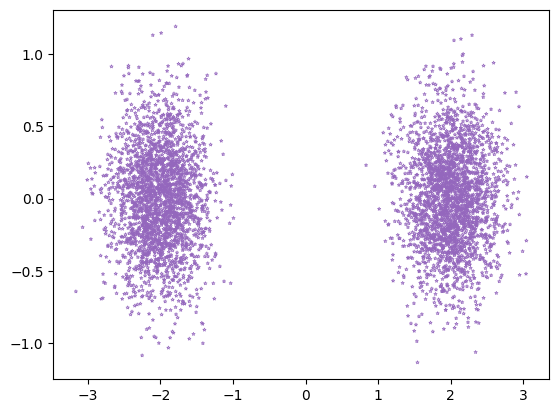

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(*next(gen)[:, :2].T, label='Ground truth', s=6.,  marker='*', facecolors='none', edgecolors='tab:purple', linewidths=0.5)

In [19]:
key, subkey = jax.random.split(key)
# <<test dataset>>
z_samples = jax.random.normal(
    subkey,
    (300, dim),
)

# Gradient flow (Picard)
Generate reference sample with Picard method

In [ ]:
init_params_gd = jax.tree.map(lambda _x: _x, init_params)
graphdep, _ = nnx.split(parametric_model)
pm_gd = nnx.merge(graphdep, init_params_gd)
history_gd = run_gradient_flow(
    pm_gd,
    z_samples,
    G_mat_flow,
    potential,
    N_samples=n_samples,
    max_iterations=max_iterations,
    h=h,
    # progress_every=max_iterations//4,
    progress_every=max_iterations*2,
    solver=solver,
    tolerance=1e-6,
)

Gradient Flow Progress:  36%|██████████████████████████████████████▎                                                                    | 179/500 [48:03<1:25:16, 15.94s/it, Energy=3.524269, Linear=0.000000, Internal=0.000000, Interaction=0.000000]

In [ ]:
final_model = history_gd.pop('final_parametric_model')
pot = history_gd.pop('potential')

In [ ]:
import pickle
import time

timestamp = time.strftime("%d.%m.%Y_%H:%M.%S")

with open(f'./{timestamp}_gf_ce_{case}.pkl', 'wb') as ofile:
    pickle.dump(history_gd, ofile)

# Anderson acceleration

In [ ]:
m = 8
beta = 1.25
reg_method = 'l2'
reg = 1e-5
graphdep, _ = nnx.split(parametric_model)
init_params_am = jax.tree.map(lambda _x: _x, init_params)
pm_anderson = nnx.merge(graphdep, init_params_am)
cp_anderson, history_anderson = anderson_method(pm_anderson, 
                                       n_samples, 
                                       z_samples, 
                                       G_mat_flow, 
                                       potential,
                                       solver=solver,
                                       initial_params=init_params,
                                       n_iterations=max_iterations, 
                                       step_size=h, 
                                       convergence_tol=1e-10,
                                       memory_size=m, 
                                       relaxation=beta, 
                                       regularization_factor_gamma=reg,
                                       regularization_method_gamma=reg_method,
                                       ensure_descent=True)

In [ ]:

with open(f'./{timestamp}_am_ce_{case}.pkl', 'wb') as ofile:
    pickle.dump(history_anderson, ofile)


# Memoryless qN

In [ ]:
from flows.memoryless_qn import memoryless_qn_method

In [ ]:
graphdep, _ = nnx.split(parametric_model)
init_params_mqn = jax.tree.map(lambda _x: _x, init_params)
pm_mqn = nnx.merge(graphdep, init_params_mqn)
cp_mqn, history_mqn = memoryless_qn_method(pm_mqn, 
                                       n_samples, 
                                       z_samples, 
                                       G_mat_flow, 
                                       potential,
                                       solver=solver,
                                       initial_params=init_params,
                                       n_iterations=max_iterations, 
                                       step_size=1e-3,
                                       hessian_update_strategy='preconvex',
                                       regularization_strategy='Li-Fukushima',
                                       spectral_scaling=True,
                                       ensure_descent=True)

# Plot results

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(20,10), sharex=True)

ax = axs[0]
e_gd = history_gd["energy_history"]
e_gd = jnp.array(e_gd)


e_am = history_anderson["energies"]
#e_am = e_gd
e_am = jnp.array(e_am)


#e_mqn = history_mqn["energies"]
#e_mqn = jnp.array(e_mqn)

#e_min = jnp.min(jnp.concatenate((e_gd, e_am, ))) - 1e1
# e_min = -1370
e_min = 0
e_gd -= e_min  # so that we can safely plot in log scale
#e_am -= e_min
#e_mqn -= e_min
ax.plot(jnp.convolve(e_gd, jnp.ones(1)/1.), label='GD')
ax.plot(jnp.convolve(e_am, jnp.ones(1)/1.), label='Anderson')
#ax.plot(e_mqn, label='Memoryless qN')
# ax.set_yscale("log")
# ax.set_ylim(1e-2, None)
ax.grid()
ax.set_title(r'$\mathcal{E} - \mathcal{E}_{\text{min}}$')

ax = axs[1]

ax.plot(history_gd['riemann_grad_norm_history'], label='GD')
#ax.plot(history_anderson['riemann_grad_history'], label='Anderson')
#ax.plot(history_mqn['riemann_grad_history'], label='Memoryless qN')
ax.set_yscale('log')
ax.grid()
ax.set_title(r"$\| \nabla_\theta F\|_{G(\theta)}$")

# ax = axs[2]
# ax.plot(history['euclid_grad_norm_history'], label='GD')
# ax.set_yscale('log')
# ax.grid()
# ax.set_title(r"$\| \nabla_\theta F\|_2$")


# ax.set_xlim((0, 200))

axs[-1].legend()

fig.tight_layout()
fig.savefig(f'{case}_convergence.pdf')

In [ ]:
import itertools


key, subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, shape=(5000, dim))


gd, _ = nnx.split(parametric_model)
# model_am = nnx.merge(gd, cp_anderson)
# sample_am = model_am(z_samples)
sample_gd = final_model(z_samples)
sample_am = sample_gd

joint_sample = jnp.concat((sample_am, sample_gd), axis=0)
l = jnp.min(joint_sample, axis=0)
r = jnp.max(joint_sample, axis=0)

bds = jnp.stack((l, r)).T

fig, ax = plt.subplots()
ax.scatter(*next(gen)[:, :2].T, label='Ground truth', s=6.,  marker='*', facecolors='none', edgecolors='tab:purple', linewidths=0.5)
ax.scatter(*sample_am[:, :2].T, label='AM', s=2., marker='*', alpha=0.5)
ax.scatter(*sample_gd[:, :2].T, label='GD', s=6.,  marker='o', facecolors='none', edgecolors='C1', linewidths=0.5, alpha=0.5)

    
ax.legend()

fig.savefig(f"{case}_scatter.pdf")

In [ ]:
gd, par = nnx.split(final_model)

par_perturbed = jax.tree.map(lambda _x: _x, par)
model = nnx.merge(gd, par_perturbed)

Z = rngs.normal((5000, 2))
X_history, tx = model(Z, history=True)
X = X_history[:, -1, :]
Z_history, tz = model.pull_back(X, history=True)
ZZ = Z_history[:, -1, :]

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(*Z.T, s=0.1)
plt.scatter(*ZZ.T, s=0.1)

In [ ]:
X = next(gen)
Z = model.pull_back(X)
XX = model(Z)

In [ ]:
plt.scatter(*Z.T, s=0.1)

In [ ]:
plt.hist(jnp.linalg.norm(X - XX, axis=-1))

In [ ]:
plt.scatter(*X.T, s=0.1)
plt.scatter(*XX.T, s=0.1)

In [ ]:
z_h, t_h = final_model.pull_back(next(gen), history=True)

In [ ]:
cm = plt.colormaps.get_cmap('Reds')
fig, ax = plt.subplots()
for i in range(z_h.shape[1]):
    ax.scatter(*z_h[:, i, :].T, s=0.1, color=cm((i + 5)/(z_h.shape[1] + 5)))

In [ ]:
# import pickle

# with open('./09.12.2025_15:34.41_gf_gaussian.pkl', 'rb') as ifile:
    # history_gd = pickle.load(ifile)
    

In [ ]:
# with open('./09.12.2025_15:34.41_am_gaussian.pkl', 'rb') as ifile:
    # history_anderson = pickle.load(ifile)

In [ ]:
! pwd